In [43]:
import tifffile as tiff
import rasterio
from rasterio.features import geometry_mask
from rasterio.features import shapes
from shapely.geometry import shape
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sys
sys.path.append("..")  # Ajouter le dossier parent au chemin
from core2.eva_losses import eva_acc, eva_dice, eva_miou, eva_sensitivity, eva_specificity
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
#from eva_losses import eva_metrics

In [ ]:
def get_metrics(ground_truth_img_path, segmentation_img_path, test_areas_path, show_images = False):

    ### Ouvrir image de Ground Truth
    with rasterio.open(ground_truth_img_path) as src:
        #print("Image ground truth:")
        #print(f"Dimensions (avant le masque)): {src.shape}") 
        #print(f"Projection : {src.crs}")
        ground_truth = src.read(1)
        src.close()

    #Importer le shapefile de la zone test
    test_areas = gpd.read_file(test_areas_path)
    #print(f"Projection des zones de test : {test_areas.crs}")

    # Créer un masque à partir des zones de test
    test_mask = geometry_mask(test_areas.geometry, transform=src.transform, invert=True, out_shape=ground_truth.shape)

    # Appliquer le masque à l'image de ground truth
    ground_truth = np.where(test_mask, ground_truth, np.nan)    

    # Vérifier qu'il y a seulement des 0 ou des 1 dans l'image
    ground_truth_nonan = ground_truth[~np.isnan(ground_truth)]
    #print(f"Dimensions de l'image ground truth après application du masque : {ground_truth_nonan.shape}")
    unique_values_nonan = np.unique(ground_truth_nonan)
    if not np.array_equal(unique_values_nonan, [0, 1]):
        print(f"Erreur: l'image ground_truth contient d'autres valeurs (en ignorant les NaN) : {unique_values_nonan}")

    # Compter le nombre de pixels de chaque classe
    #unique, counts = np.unique(ground_truth_nonan, return_counts=True)
    #print("Nombre de pixels par classe :")
    #for value, count in zip(unique, counts):
    #    print(f"Classe {value}: {count} pixels")
    #print(f"proportion de pixels de la classe 1: {counts[1] / (counts[0] + counts[1]) * 100:.2f}%")

    #visualiser l'image de labels
    if show_images:
        plt.imshow(ground_truth, cmap="gray")
        plt.colorbar()
        plt.title("Image de ground_truth")
        plt.show()


    ### Ouvrir image de segmentation (output du modèle)r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_JRW45_vrai_train_valid_test\10_epoch_train_valid_test\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_inference_inference_seg.tif"
    with rasterio.open(segmentation_img_path) as src:
        #print("Image de segmentation")
        #print(f"Dimensions (avant le masque): {src.shape}")
        segmentation = src.read(1)
        src.close()

    # Créer un masque à partir des zones de test
    segmentation = np.where(test_mask, segmentation, np.nan)
    
    # Vérifier qu'il y a seulement des 0 ou des 1 dans l'image  
    segmentation_nonan = segmentation[~np.isnan(segmentation)]
    #print(f"Dimensions de l'image de segmentation après application du masque : {segmentation_nonan.shape}")

    #Vérifier que segmentation_nonan et ground_truth_nonan ont la même forme
    if segmentation_nonan.shape != ground_truth_nonan.shape:
        print(f"Erreur: les images de segmentation et de ground truth n'ont pas la même forme : {segmentation_nonan.shape} vs {ground_truth_nonan.shape}")
        return None, None

    unique_values_nonan = np.unique(segmentation_nonan)
    if not np.array_equal(unique_values_nonan, [0, 1]):
        print(f"Erreur: l'image de segmentation contient d'autres valeurs (en ignorant les NaN) : {unique_values_nonan}")

    # Compter le nombre de pixels de chaque classe
    #unique, counts = np.unique(segmentation_nonan, return_counts=True)
    #print("Nombre de pixels par classe :")
    #for value, count in zip(unique, counts):
    #    print(f"Classe {value}: {count} pixels")
    #print(f"proportion de pixels de la classe 1: {counts[1] / (counts[0] + counts[1]) * 100:.2f}%")

    #visualiser l'image de segmentation
    if show_images:
        plt.imshow(segmentation, cmap="gray")
        plt.colorbar()
        plt.title("Image de segmentation")
        plt.show()

    ### Calculer les métriques
    eva_acc_value = eva_acc(ground_truth_nonan, segmentation_nonan)
    #eva_dice_value = eva_dice(ground_truth_nonan, segmentation_nonan) La même chose que le f1 score
    eva_miou_value = eva_miou(ground_truth_nonan, segmentation_nonan)
    eva_sensitivity_value = eva_sensitivity(ground_truth_nonan, segmentation_nonan)
    eva_specificity_value = eva_specificity(ground_truth_nonan, segmentation_nonan)

    #fonction de scikit-learn pour calculer les métriques
    #acc = accuracy_score(ground_truth_nonan.flatten(), segmentation_nonan.flatten())
    f1 = f1_score(ground_truth_nonan.flatten(), segmentation_nonan.flatten())
    precision = precision_score(ground_truth_nonan.flatten(), segmentation_nonan.flatten())
    recall = recall_score(ground_truth_nonan.flatten(), segmentation_nonan.flatten())
    roc_auc_score_value = roc_auc_score(ground_truth_nonan.flatten(), segmentation_nonan.flatten())  
    cm = confusion_matrix(ground_truth_nonan.flatten(), segmentation_nonan.flatten())  

    metrics_df = pd.DataFrame({
        "acc": [eva_acc_value],
        "f1": [f1],
        "precision": [precision],
        "recall": [recall],
        "miou": [eva_miou_value],
        "sensitivity": [eva_sensitivity_value],
        "specificity": [eva_specificity_value],
        "roc_auc": [roc_auc_score_value]
    })

    return metrics_df, cm


def segmentation_tif_to_shapefile(segmentation_path, reference_path, shapefile_path, threshold=0.5, min_area=None):
    """
    Convertit une image de segmentation (.tif) en shapefile (.shp) en utilisant la géoréférence d'un fichier de référence.

    Args:
        segmentation_path (str): Chemin du fichier TIF contenant la prédiction (0/1 ou float [0-1]).
        reference_path (str): Chemin du fichier image géoréférencé (ex: ground_truth.png).
        shapefile_path (str): Chemin de sortie pour le shapefile (.shp).
        threshold (float): Seuil pour binariser la segmentation si besoin (default = 0.5).
        min_area (float): Supprimer les polygones plus petits que cette surface (en unités CRS).
    """

    # 1. Lire le géoréférencement de la référence
    with rasterio.open(reference_path) as src_ref:
        gt_transform = src_ref.transform
        gt_crs = src_ref.crs

    # 2. Lire l'image de segmentation
    with rasterio.open(segmentation_path) as src_seg:
        seg_data = src_seg.read(1)  # lire bande unique

    # 3. Binariser si besoin
    mask = (seg_data > threshold).astype(np.uint8)

    # 4. Extraire les polygones
    polygons = []
    for geom, value in shapes(mask, transform=gt_transform):
        if value == 1:
            poly = shape(geom)
            if min_area is None or poly.area >= min_area:
                polygons.append(poly)

    # 5. Construire le GeoDataFrame
    gdf = gpd.GeoDataFrame(geometry=polygons, crs=gt_crs)

    # 6. Sauvegarder en shapefile
    gdf.to_file(shapefile_path)

    print(f"Shapefile sauvegardé : {shapefile_path} ({len(gdf)} polygones)")


## Entraînement sur un seul site JRW45

In [23]:
ground_truth_img_path= r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_JRW45_vrai_train_valid_test\0_epoch_train_valid_test\gt_all.png"
segmentation_img_path = r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_JRW45_vrai_train_valid_test\0_epoch_train_valid_test\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_inference_inference_seg.tif"

#Métriques en train
print("train epoch 0")
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)

#Métriques en val
print("Val epoch 0")
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)

#Métriques en test
#print("Test")
#test_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\test_areas.shp'
#metrics_test = get_metrics(ground_truth_img_path, segmentation_img_path, test_areas_path)

#Combiner les métriques dans un DataFrame
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["Train", "Validation"]).reset_index(level=1, drop=True)

print(metrics_combined)

#Print confusion matrix
print(metrics_val[1])

#output to csv
metrics_combined.to_csv(r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_JRW45_vrai_train_valid_test\0_epoch_train_valid_test\metrics_combined.csv")


train epoch 0
Dimensions de l'image ground truth après application du masque : (11891931,)
Dimensions de l'image de segmentation après application du masque : (11891931,)
Val epoch 0
Dimensions de l'image ground truth après application du masque : (1961181,)
Dimensions de l'image de segmentation après application du masque : (1961181,)
                 acc        f1  precision    recall      miou  sensitivity  \
Train       0.766238  0.076166   0.720142  0.040209  0.401777     0.040209   
Validation  0.766483  0.111345   0.666318  0.060748  0.410985     0.060748   

            specificity   roc_auc  
Train          0.995075  0.517642  
Validation     0.990350  0.525549  
[[1474520   14368]
 [ 443602   28691]]


train epoch 10
Dimensions de l'image ground truth après application du masque : (11891931,)
Dimensions de l'image de segmentation après application du masque : (11891931,)
Val epoch 10
Dimensions de l'image ground truth après application du masque : (1961181,)


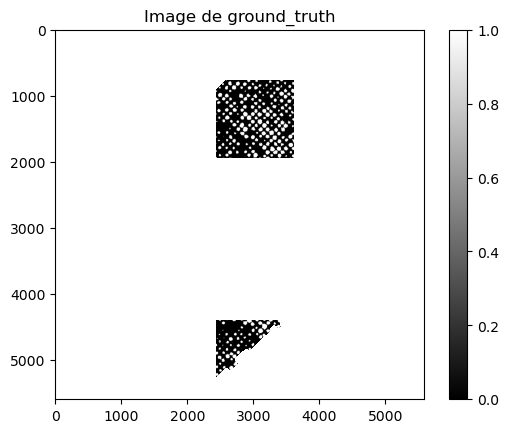

Dimensions de l'image de segmentation après application du masque : (1961181,)


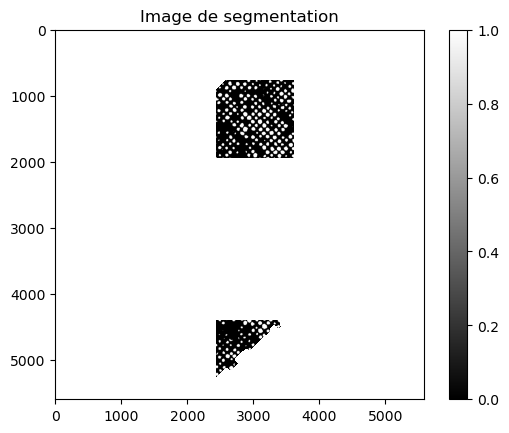

                 acc        f1  precision    recall      miou  sensitivity  \
Train       0.959434  0.913240   0.936756  0.890876  0.894377     0.890876   
Validation  0.947963  0.884891   0.946841  0.830550  0.864250     0.830550   

            specificity   roc_auc  
Train          0.981042  0.935959  
Validation     0.985208  0.907879  
[[1466865   22023]
 [  80030  392263]]


In [24]:
ground_truth_img_path= r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_JRW45_vrai_train_valid_test\10_epoch_train_valid_test\gt_all.png"
segmentation_img_path = r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_JRW45_vrai_train_valid_test\10_epoch_train_valid_test\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_inference_inference_seg.tif"

#Métriques en train
print("train epoch 10")
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)

#Métriques en val
print("Val epoch 10")
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path, show_images=True)

#Métriques en test
#print("Test")
#test_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\test_areas.shp'
#metrics_test = get_metrics(ground_truth_img_path, segmentation_img_path, test_areas_path)

#Combiner les métriques dans un DataFrame (exclure la matrice de confusion)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["Train", "Validation"]).reset_index(level=1, drop=True)

print(metrics_combined)

#print confusion matrix
print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_JRW45_vrai_train_valid_test\10_epoch_train_valid_test\metrics_combined.csv")

## Entraînement sur un seul site Fdc_JR_East_GCA

train epoch 10
Dimensions de l'image ground truth après application du masque : (15080863,)
Dimensions de l'image de segmentation après application du masque : (15080863,)
Val epoch 10
Dimensions de l'image ground truth après application du masque : (1991458,)


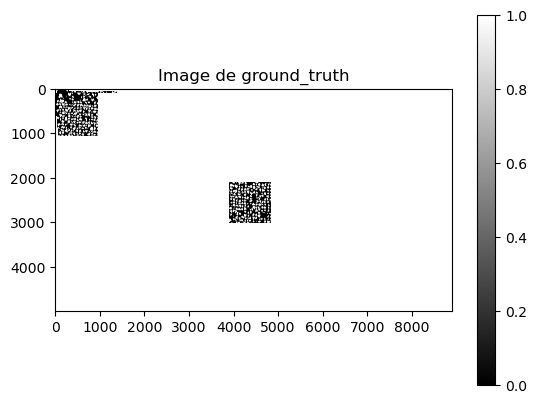

Dimensions de l'image de segmentation après application du masque : (1991458,)


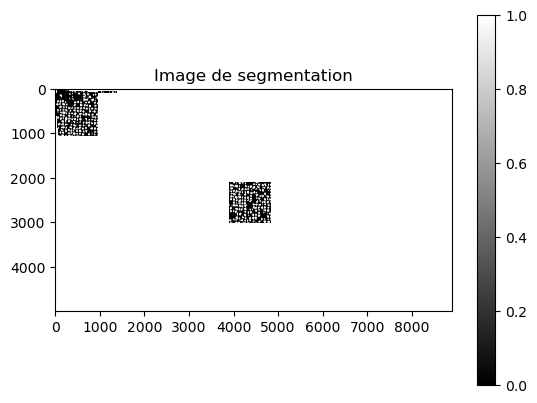

                 acc        f1  precision    recall      miou  sensitivity  \
Train       0.841937  0.748630   0.776007  0.723118  0.695765     0.723118   
Validation  0.841422  0.761194   0.819564  0.710586  0.701124     0.710586   

            specificity   roc_auc  
Train          0.899275  0.811197  
Validation     0.913644  0.812115  
[[1172349  110809]
 [ 204992  503308]]


In [ ]:
ground_truth_img_path= r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_Fdc_JR_East_GCA\ground_truth_Fdc_JR_East_GCA.png"
segmentation_img_path = r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_Fdc_JR_East_GCA\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"

#Métriques en train
print("train epoch 10")
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)

#Métriques en val
print("Val epoch 10")
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path, show_images=True)

#Métriques en test
#print("Test")
#test_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\test_areas.shp'
#metrics_test = get_metrics(ground_truth_img_path, segmentation_img_path, test_areas_path)

#Combiner les métriques dans un DataFrame (exclure la matrice de confusion)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["Train", "Validation"]).reset_index(level=1, drop=True)

print(metrics_combined)

#print confusion matrix
print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\données_pour_metric\Données_Fdc_JR_East_GCA\metrics_combined.csv")

## Entraînement sur tous les sites

### Images RGB Boundary weight = 2

In [54]:
bw="2"

ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = rf'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw{bw}'
output_metrics_path = rf"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGB_bw{bw}_metrics_combined.csv"

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["CW JR East Train", "CW JR East Validation"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_East_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_Sandcut_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_East_GCA_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_W45_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_PR_Canoe_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(output_metrics_path)


Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw2\Cw_JR_East_predicted_crowns_RGB_bw2.shp (3530 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw2\Cw_JR_Sandcut_predicted_crowns_RGB_bw2.shp (1211 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw2\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw2.shp (1614 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw2\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw2.shp (950 polygones)
Erreur: l'image de segmentation contient d'autres valeurs (en ignorant les NaN) : [0.]


c:\Users\sinadeau\AppData\Local\miniconda3\envs\ML_3.12.7\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw2\Fdc_JR_East_GCA_predicted_crowns_RGB_bw2.shp (6 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw2\Fdc_JR_W45_predicted_crowns_RGB_bw2.shp (2113 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw2\Fdc_PR_Canoe_predicted_crowns_RGB_bw2.shp (115 polygones)
                                     acc        f1  precision    recall  \
CW JR East Train                0.801445  0.612203   0.840294  0.481503   
CW JR East Validation           0.804980  0.654116   0.885877  0.518474   
Cw JR Sandcut Train             0.694973  0.080529   0.714880  0.042668   
Cw JR Sandcut Validation        0.699873  0.030174   0.713583  0.015413   
Cw_PR_Rainbow_SiteA Train       0.771970  0.769164   0.828396  0

### Images RGB Boundary weight = 3

In [47]:
bw="3"

ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = rf'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw{bw}'
output_metrics_path = rf"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGB_bw{bw}_metrics_combined.csv"

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["CW JR East Train", "CW JR East Validation"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_East_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_Sandcut_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_East_GCA_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_W45_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_PR_Canoe_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(output_metrics_path)


Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3\Cw_JR_East_predicted_crowns_RGB_bw3.shp (5206 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3\Cw_JR_Sandcut_predicted_crowns_RGB_bw3.shp (5763 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw3.shp (1632 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw3.shp (989 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3\Fdc_JR_East_GCA_predicted_crowns_RGB_bw3.shp (1648 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneD

### Images RGB  Boundary weight = 4

In [52]:
bw="4"

ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = rf'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw{bw}'
output_metrics_path = rf"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGB_bw{bw}_metrics_combined.csv"

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["CW JR East Train", "CW JR East Validation"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_East_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_Sandcut_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_East_GCA_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_W45_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_PR_Canoe_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(output_metrics_path)


Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw4\Cw_JR_East_predicted_crowns_RGB_bw4.shp (3811 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw4\Cw_JR_Sandcut_predicted_crowns_RGB_bw4.shp (1866 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw4\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw4.shp (1633 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw4\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw4.shp (987 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw4\Fdc_JR_East_GCA_predicted_crowns_RGB_bw4.shp (78 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDri

### Images RGB  Boundary weight = 5

In [50]:
bw="5"

ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = rf'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw{bw}'
output_metrics_path = rf"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGB_bw{bw}_metrics_combined.csv"

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["CW JR East Train", "CW JR East Validation"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_East_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_Sandcut_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_East_GCA_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_W45_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_PR_Canoe_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(output_metrics_path)

Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw5\Cw_JR_East_predicted_crowns_RGB_bw5.shp (4331 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw5\Cw_JR_Sandcut_predicted_crowns_RGB_bw5.shp (2850 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw5\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw5.shp (1752 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw5\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw5.shp (1106 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw5\Fdc_JR_East_GCA_predicted_crowns_RGB_bw5.shp (116 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneD

### Images RGB+NIR  Boundary weight = 1.1

In [51]:
bw="1_1"

ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = rf'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw{bw}'
output_metrics_path = rf"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGBNIR_bw{bw}_metrics_combined.csv"

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["CW JR East Train", "CW JR East Validation"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_East_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_Sandcut_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteA_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteB_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_East_GCA_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_W45_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_PR_Canoe_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(output_metrics_path)

Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw1_1\Cw_JR_East_predicted_crowns_RGBNIR_bw1_1.shp (4128 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw1_1\Cw_JR_Sandcut_predicted_crowns_RGBNIR_bw1_1.shp (2627 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw1_1\Cw_PR_Rainbow_SiteA_predicted_crowns_RGBNIR_bw1_1.shp (1343 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw1_1\Cw_PR_Rainbow_SiteB_predicted_crowns_RGBNIR_bw1_1.shp (807 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw1_1\Fdc_JR_East_GCA_predicted_crowns_RGBNIR_bw1_1.shp (1504 polygo

### Images RGB+NIR  Boundary weight = 1.5

In [48]:
bw="1_5"

ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = rf'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw{bw}'
output_metrics_path = rf"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGBNIR_bw{bw}_metrics_combined.csv"

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["CW JR East Train", "CW JR East Validation"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_East_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_Sandcut_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteA_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteB_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_East_GCA_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_W45_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_PR_Canoe_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(output_metrics_path)

Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw1_5\Cw_JR_East_predicted_crowns_RGBNIR_bw1_5.shp (3793 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw1_5\Cw_JR_Sandcut_predicted_crowns_RGBNIR_bw1_5.shp (2825 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw1_5\Cw_PR_Rainbow_SiteA_predicted_crowns_RGBNIR_bw1_5.shp (1354 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw1_5\Cw_PR_Rainbow_SiteB_predicted_crowns_RGBNIR_bw1_5.shp (747 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw1_5\Fdc_JR_East_GCA_predicted_crowns_RGBNIR_bw1_5.shp (1552 polygo

### Images RGB+NIR  Boundary weight = 2.5

In [46]:
bw="2_5"

ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = rf'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw{bw}'
output_metrics_path = rf"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGBNIR_bw{bw}_metrics_combined.csv"

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["CW JR East Train", "CW JR East Validation"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_East_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_Sandcut_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteA_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteB_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_East_GCA_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_W45_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_PR_Canoe_predicted_crowns_RGBNIR_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(output_metrics_path)

Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw2_5\Cw_JR_East_predicted_crowns_RGBNIR_bw2_5.shp (5362 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw2_5\Cw_JR_Sandcut_predicted_crowns_RGBNIR_bw2_5.shp (3119 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw2_5\Cw_PR_Rainbow_SiteA_predicted_crowns_RGBNIR_bw2_5.shp (2115 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw2_5\Cw_PR_Rainbow_SiteB_predicted_crowns_RGBNIR_bw2_5.shp (1287 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw2_5\Fdc_JR_East_GCA_predicted_crowns_RGBNIR_bw2_5.shp (1662 polyg

### Images RGB+NIR  Boundary weight = 3

In [ ]:
ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw3'

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["CW JR East Train", "CW JR East Validation"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + r'\Cw_JR_East_predicted_crowns.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + r'\Cw_JR_Sandcut_predicted_crowns.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + r'\Cw_PR_Rainbow_SiteA_predicted_crowns.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + r'\Cw_PR_Rainbow_SiteB_predicted_crowns.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + r'\Fdc_JR_East_GCA_predicted_crowns.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + r'\Fdc_JR_W45_predicted_crowns.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGBNIR_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + r'\Fdc_PR_Canoe_predicted_crowns.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(r"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGBNIR_bw3_metrics_combined.csv")

Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw3\Cw_JR_East_predicted_crowns.shp (4918 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw3\Cw_JR_Sandcut_predicted_crowns.shp (3282 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw3\Cw_PR_Rainbow_SiteA_predicted_crowns.shp (2001 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw3\Cw_PR_Rainbow_SiteB_predicted_crowns.shp (1149 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGBNIR_bw3\Fdc_JR_East_GCA_predicted_crowns.shp (1673 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_

## Entraînement en utilisation seulement une espèce

### Sites cèdre rouge de l'ouest (Cw), Images RGB  Boundary weight = 3

In [55]:
bw="3"
train_species="Cw"

ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = rf'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw{bw}_train_on_{train_species}'
output_metrics_path = rf"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGB_bw{bw}_train_on_{train_species}_metrics_combined.csv"

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["CW JR East Train", "CW JR East Validation"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_East_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_Sandcut_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_East_GCA_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_W45_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_PR_Canoe_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(output_metrics_path)

Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train_on_Cw\Cw_JR_East_predicted_crowns_RGB_bw3_train_on_Cw.shp (6040 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train_on_Cw\Cw_JR_Sandcut_predicted_crowns_RGB_bw3_train_on_Cw.shp (2835 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train_on_Cw\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw3_train_on_Cw.shp (2936 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train_on_Cw\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw3_train_on_Cw.shp (1714 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train_on_C

### Sites sapin de douglas (Fdc), Images RGB  Boundary weight = 3

In [58]:
bw="3"
train_species="Fdc"

ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = rf'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw{bw}_train_on_{train_species}'
output_metrics_path = rf"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGB_bw{bw}_train_on_{train_species}_metrics_combined.csv"

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["CW JR East Train", "CW JR East Validation"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_East_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_Sandcut_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_East_GCA_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_W45_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_PR_Canoe_predicted_crowns_RGB_bw{bw}_train_on_{train_species}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(output_metrics_path)

Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train_on_Fdc\Cw_JR_East_predicted_crowns_RGB_bw3_train_on_Fdc.shp (694 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train_on_Fdc\Cw_JR_Sandcut_predicted_crowns_RGB_bw3_train_on_Fdc.shp (1466 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train_on_Fdc\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw3_train_on_Fdc.shp (370 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train_on_Fdc\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw3_train_on_Fdc.shp (517 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train

c:\Users\sinadeau\AppData\Local\miniconda3\envs\ML_3.12.7\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train_on_Fdc\Fdc_JR_W45_predicted_crowns_RGB_bw3_train_on_Fdc.shp (25 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_train_on_Fdc\Fdc_PR_Canoe_predicted_crowns_RGB_bw3_train_on_Fdc.shp (216 polygones)
                                     acc        f1  precision    recall  \
CW JR East Train                0.673612  0.011691   0.405974  0.005931   
CW JR East Validation           0.641691  0.007378   0.251089  0.003744   
Cw JR Sandcut Train             0.687866  0.016971   0.603277  0.008607   
Cw JR Sandcut Validation        0.698055  0.014643   0.639175  0.007406   
Cw_PR_Rainbow_SiteA Train       0.476475  0.022748   0.941253  0.011513   
Cw_PR_Rainbow_SiteA Validation  0.463360  0.027048   0.912682  0.013727   
Cw_PR_Rainbow_SiteB Train       0.418601  0.060895  

## Entraînement sur tous les sites, mais sans le site problématique Fdc_canoe

In [59]:
bw="3"

ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = rf'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw{bw}_wo_canoe'
output_metrics_path = rf"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGB_bw{bw}_wo_canoe_metrics_combined.csv"

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0]], keys=["CW JR East Train", "CW JR East Validation"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_East_predicted_crowns_RGB_bw{bw}_wo_canoe.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_Sandcut_predicted_crowns_RGB_bw{bw}_wo_canoe.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw{bw}_wo_canoe.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw{bw}_wo_canoe.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_East_GCA_predicted_crowns_RGB_bw{bw}_wo_canoe.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_W45_predicted_crowns_RGB_bw{bw}_wo_canoe.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_PR_Canoe_predicted_crowns_RGB_bw{bw}_wo_canoe.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(output_metrics_path)

Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_wo_canoe\Cw_JR_East_predicted_crowns_RGB_bw3_wo_canoe.shp (4394 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_wo_canoe\Cw_JR_Sandcut_predicted_crowns_RGB_bw3_wo_canoe.shp (5192 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_wo_canoe\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw3_wo_canoe.shp (1776 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_wo_canoe\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw3_wo_canoe.shp (995 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3_wo_canoe\Fdc_JR_East_GCA_predicted_

## Modèle final

### Évaluation sur le jeu de test

In [61]:
bw="3"

ground_truth_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\preprocessing_plantation_RGB\preprocessing_plantation_RGB'
predictions_path = rf'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw{bw}'
output_metrics_path = rf"C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\all_sites_RGB_bw{bw}_metrics_combined.csv"

#Site CW JR East
ground_truth_img_path = ground_truth_path + r"\Cw_JR_East\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\val_areas.shp'
test_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_East\train_test_split\test_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_test = get_metrics(ground_truth_img_path, segmentation_img_path, test_areas_path)
metrics_combined = pd.concat([metrics_train[0], metrics_val[0], metrics_test[0]], keys=["CW JR East Train", "CW JR East Validation", "CW JR East Test"]).reset_index(level=1, drop=True)
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_East_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_JR_Sandcut
ground_truth_img_path = ground_truth_path + r"\Cw_JR_Sandcut\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_JR_Sandcut_2022_05_25_pan_IMG_0012_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\val_areas.shp'
test_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_JR_Sandcut\train_test_split\test_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_test = get_metrics(ground_truth_img_path, segmentation_img_path, test_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0], metrics_test[0]], keys=["Cw JR Sandcut Train", "Cw JR Sandcut Validation", "Cw JR Sandcut Test"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_JR_Sandcut_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteA
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\val_areas.shp'
test_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteA\train_test_split\test_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_test = get_metrics(ground_truth_img_path, segmentation_img_path, test_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0], metrics_test[0]], keys=["Cw_PR_Rainbow_SiteA Train", "Cw_PR_Rainbow_SiteA Validation", "Cw_PR_Rainbow_SiteA Test"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Site Cw_PR_Rainbow_SiteB
ground_truth_img_path = ground_truth_path + r"\Cw_PR_Rainbow_SiteB\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Cw_PR_Rainbow_plotB_2022_05_26_MS_Calibrated_p11_bestPanel_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\val_areas.shp'
test_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Cw_PR_Rainbow_SiteB\train_test_split\test_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_test = get_metrics(ground_truth_img_path, segmentation_img_path, test_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0], metrics_test[0]], keys=["Cw_PR_Rainbow_SiteB Train", "Cw_PR_Rainbow_SiteB Validation", "Cw_PR_Rainbow_SiteB Test"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_East_GCA
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_East_GCA\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_East_GCA_2022_05_24_pan_IMG_0007_6_MS_alP1_cor2_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\val_areas.shp'
test_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_East_GCA\train_test_split\test_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_test = get_metrics(ground_truth_img_path, segmentation_img_path, test_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0], metrics_test[0]], keys=["Fdc_JR_East_GCA Train", "Fdc_JR_East_GCA Validation", "Fdc_JR_East_GCA Test"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_East_GCA_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

#Fdc_JR_W45
ground_truth_img_path = ground_truth_path + r"\Fdc_JR_W45\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\val_areas.shp'
test_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_JR_W45\train_test_split\test_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_test = get_metrics(ground_truth_img_path, segmentation_img_path, test_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0], metrics_test[0]], keys=["Fdc_JR_W45 Train", "Fdc_JR_W45 Validation", "Fdc_JR_W45 Test"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_JR_W45_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )


#Fdc_PR_Canoe
ground_truth_img_path = ground_truth_path + r"\Fdc_PR_Canoe\groundtruth\annotation_0.png"
segmentation_img_path = predictions_path + r"\Fdc_PR_Canoe_2022_06_08_MS_Calibrated_p1219_bestPanel-001_clean_RGB_only_region_to_segment_seg.tif"
train_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\train_areas.shp'
val_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\val_areas.shp'
test_areas_path = r'C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\Fdc_PR_Canoe\train_test_split\test_areas.shp'
metrics_train = get_metrics(ground_truth_img_path, segmentation_img_path, train_areas_path)
metrics_val = get_metrics(ground_truth_img_path, segmentation_img_path, val_areas_path)
metrics_test = get_metrics(ground_truth_img_path, segmentation_img_path, test_areas_path)
metrics_combined_tmp = pd.concat([metrics_train[0], metrics_val[0], metrics_test[0]], keys=["Fdc_PR_Canoe Train", "Fdc_PR_Canoe Validation", "Fdc_PR_Canoe Test"]).reset_index(level=1, drop=True)
metrics_combined = pd.concat([metrics_combined, metrics_combined_tmp])
#Pour visualisation
segmentation_tif_to_shapefile(segmentation_path=segmentation_img_path, reference_path=ground_truth_img_path, 
                              shapefile_path=predictions_path + rf'\Fdc_PR_Canoe_predicted_crowns_RGB_bw{bw}.shp', 
                              threshold=0.5, min_area=None  # optionnel
                              )

print(metrics_combined)

#print confusion matrix
#print(metrics_val[-1])

#output to csv
metrics_combined.to_csv(output_metrics_path)


Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3\Cw_JR_East_predicted_crowns_RGB_bw3.shp (5206 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3\Cw_JR_Sandcut_predicted_crowns_RGB_bw3.shp (5763 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3\Cw_PR_Rainbow_SiteA_predicted_crowns_RGB_bw3.shp (1632 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3\Cw_PR_Rainbow_SiteB_predicted_crowns_RGB_bw3.shp (989 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneDrive - NRCan RNCan\data_glo7030-projet\inference_plantation_RGB\predictions_RGB_bw3\Fdc_JR_East_GCA_predicted_crowns_RGB_bw3.shp (1648 polygones)
Shapefile sauvegardé : C:\Users\sinadeau\OneD